<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Visualization**


Estimated time needed: **45** minutes


In this lab, you will focus on data visualization. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


After completing this lab, you will be able to:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize composition and comparison of data.




## Demo: How to work with database


Download the database file.


In [77]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

**Install and Import Necessary Python Libraries**

Ensure that you have the required libraries installed to work with SQLite and Pandas:


In [78]:
#!pip install pandas 
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

**Read the CSV File into a Pandas DataFrame**

Load the Stack Overflow survey data into a Pandas DataFrame:


In [79]:
# Read the CSV file
df = pd.read_csv('survey_data-for-visualization-labs.csv')

# Display the first few rows of the data
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


**Create a SQLite Database and Insert the Data**

Now, let's create a new SQLite database (`survey-data.sqlite`) and insert the data from the DataFrame into a table using the sqlite3 library:


In [80]:
import sqlite3

# Create a connection to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Write the dataframe to the SQLite database
df.to_sql('main', conn, if_exists='replace', index=False)


# Close the connection
conn.close()


**Verify the Data in the SQLite Database**
Verify that the data has been correctly inserted into the SQLite database by running a simple query:


In [81]:
# Reconnect to the SQLite database
conn = sqlite3.connect('survey-data.sqlite')

# Run a simple query to check the data
QUERY = "SELECT * FROM main LIMIT 5"
df_check = pd.read_sql_query(QUERY, conn)

# Display the results
print(df_check)


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

## Demo: Running an SQL Query


Count the number of rows in the table named 'main'


In [82]:
QUERY = """
SELECT COUNT(*) 
FROM main
"""
df = pd.read_sql_query(QUERY, conn)
df.head()


,COUNT(*)
0,65437


## Demo: Listing All Tables


To view the names of all tables in the database:


In [83]:
QUERY = """
SELECT name as Table_Name FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


## Demo: Running a Group By Query
    
For example, you can group data by a specific column, like Age, to get the count of respondents in each age group:


In [84]:
QUERY = """
SELECT Age, COUNT(*) as count
FROM main
GROUP BY Age
ORDER BY Age
"""
pd.read_sql_query(QUERY, conn)


,Age,count
0,18-24 years old,14098
1,25-34 years old,23911
2,35-44 years old,14942
3,45-54 years old,6249
4,55-64 years old,2575
5,65 years or older,772
6,Prefer not to say,322
7,Under 18 years old,2568


## Demo: Describing a table

Use this query to get the schema of a specific table, main in this case:


In [85]:
table_name = 'main'

QUERY = """
SELECT sql FROM sqlite_master 
WHERE name= '{}'
""".format(table_name)

df = pd.read_sql_query(QUERY, conn)
print(df.iat[0,0])


CREATE TABLE "main" (
"ResponseId" INTEGER,
  "MainBranch" TEXT,
  "Age" TEXT,
  "Employment" TEXT,
  "RemoteWork" TEXT,
  "Check" TEXT,
  "CodingActivities" TEXT,
  "EdLevel" TEXT,
  "LearnCode" TEXT,
  "LearnCodeOnline" TEXT,
  "TechDoc" TEXT,
  "YearsCode" TEXT,
  "YearsCodePro" TEXT,
  "DevType" TEXT,
  "OrgSize" TEXT,
  "PurchaseInfluence" TEXT,
  "BuyNewTool" TEXT,
  "BuildvsBuy" TEXT,
  "TechEndorse" TEXT,
  "Country" TEXT,
  "Currency" TEXT,
  "CompTotal" REAL,
  "LanguageHaveWorkedWith" TEXT,
  "LanguageWantToWorkWith" TEXT,
  "LanguageAdmired" TEXT,
  "DatabaseHaveWorkedWith" TEXT,
  "DatabaseWantToWorkWith" TEXT,
  "DatabaseAdmired" TEXT,
  "PlatformHaveWorkedWith" TEXT,
  "PlatformWantToWorkWith" TEXT,
  "PlatformAdmired" TEXT,
  "WebframeHaveWorkedWith" TEXT,
  "WebframeWantToWorkWith" TEXT,
  "WebframeAdmired" TEXT,
  "EmbeddedHaveWorkedWith" TEXT,
  "EmbeddedWantToWorkWith" TEXT,
  "EmbeddedAdmired" TEXT,
  "MiscTechHaveWorkedWith" TEXT,
  "MiscTechWantToWorkWith" TEXT,


## Hands-on Lab


### Visualizing the Distribution of Data

**Histograms**

Plot a histogram of CompTotal (Total Compensation).


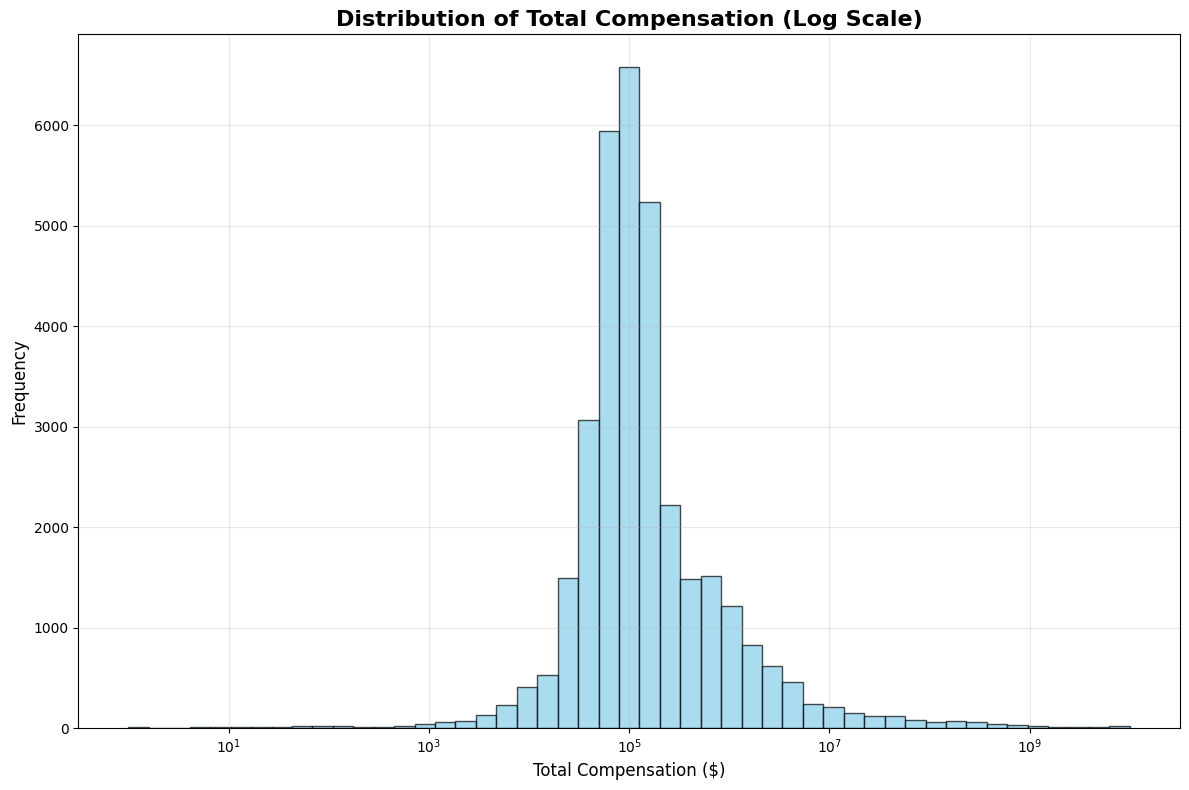

In [86]:
## Write your code here

# Query to get CompTotal data
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL AND CompTotal > 0"
df = pd.read_sql_query(QUERY, conn)

# Create histogram with better scaling
plt.figure(figsize=(12, 8))

# Use logarithmic scale for better visualization of wide range data
plt.hist(df['CompTotal'], bins=np.logspace(0, 10, 50), color='skyblue', edgecolor='black', alpha=0.7)
plt.xscale('log')  # Set x-axis to logarithmic scale
plt.title('Distribution of Total Compensation (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Total Compensation ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

**Box Plots**

Plot a box plot of Age.


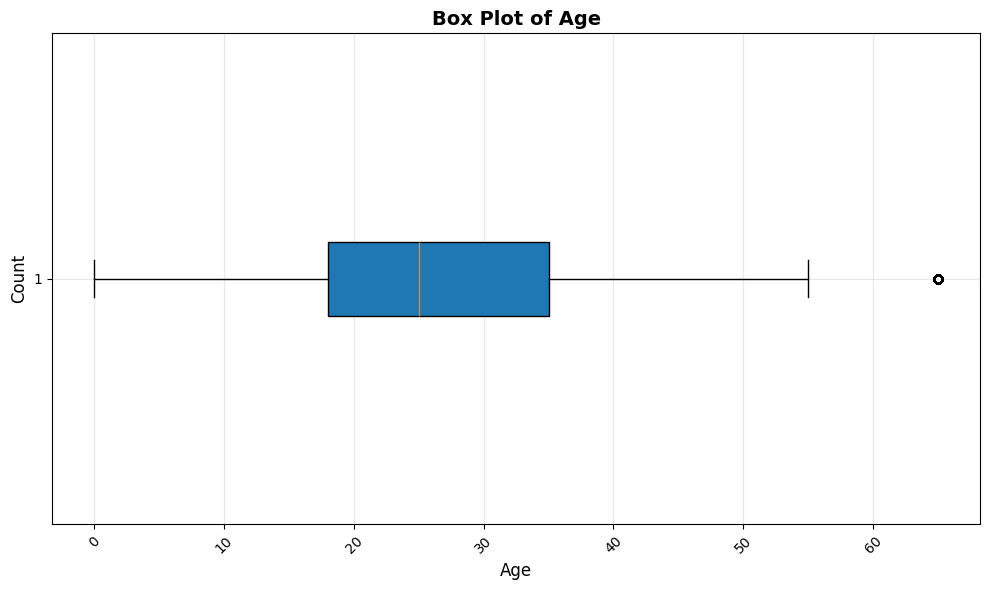

In [87]:
## Write your code here

# Query to get Age data
QUERY = "SELECT Age FROM main"
df_age = pd.read_sql_query(QUERY, conn)

# Convert Age to numeric (handle categorical age groups)
df_age['Age'] = df_age['Age'].astype(str).str.replace(' years old', '').str.replace('Under 18', '0').str.replace('18-24', '18').str.replace('25-34', '25').str.replace('35-44', '35').str.replace('45-54', '45').str.replace('55-64', '55').str.replace('65 years or older', '65').str.replace('Prefer not to say', '0').astype(float)

# Create box plot of Age
plt.figure(figsize=(10, 6))
plt.boxplot(df_age['Age'], vert=False, patch_artist=True)
plt.title('Box Plot of Age', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Visualizing Relationships in Data

**Scatter Plots**

Create a scatter plot of Age and WorkExp.


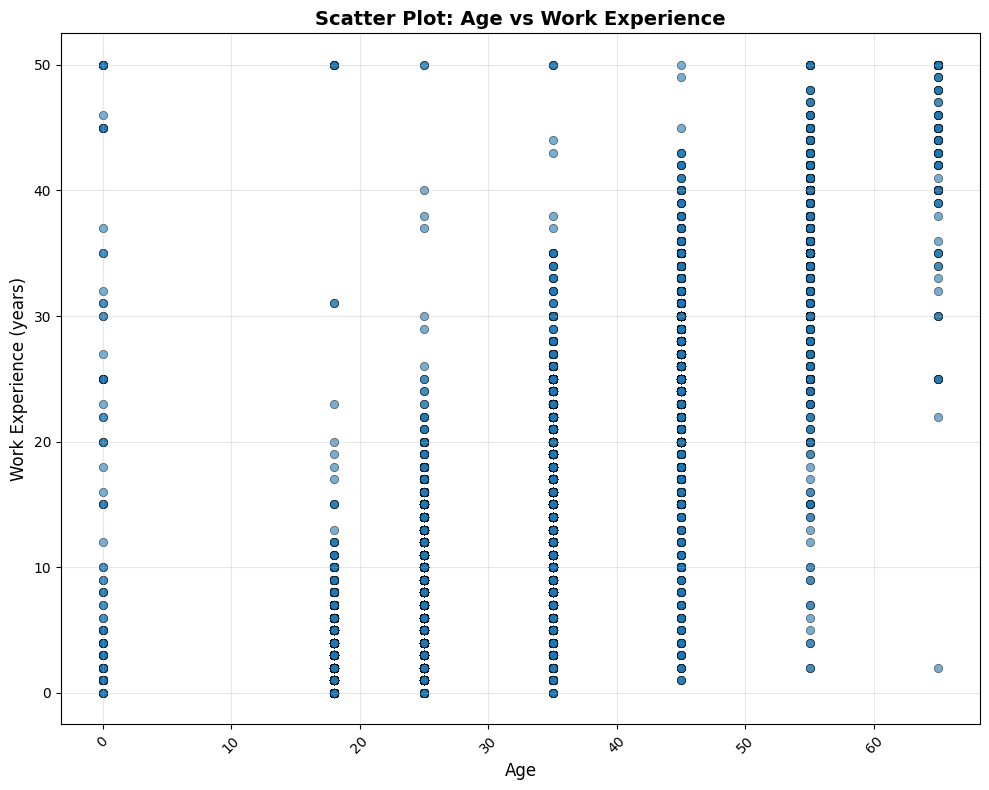

In [88]:
## Write your code here

# Query to get Age and WorkExp data
QUERY = "SELECT Age, WorkExp FROM main"
df_scatter = pd.read_sql_query(QUERY, conn)

# Convert Age to numeric
df_scatter['Age'] = df_scatter['Age'].astype(str).str.replace(' years old', '').str.replace('Under 18', '0').str.replace('18-24', '18').str.replace('25-34', '25').str.replace('35-44', '35').str.replace('45-54', '45').str.replace('55-64', '55').str.replace('65 years or older', '65').str.replace('Prefer not to say', '0').astype(float)

# Create scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(df_scatter['Age'], df_scatter['WorkExp'], alpha=0.6, edgecolors='black', linewidth=0.5)
plt.title('Scatter Plot: Age vs Work Experience', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Work Experience (years)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Bubble Plots**

Create a bubble plot of `TimeSearching` and `Frustration` using the Age column as the bubble size.


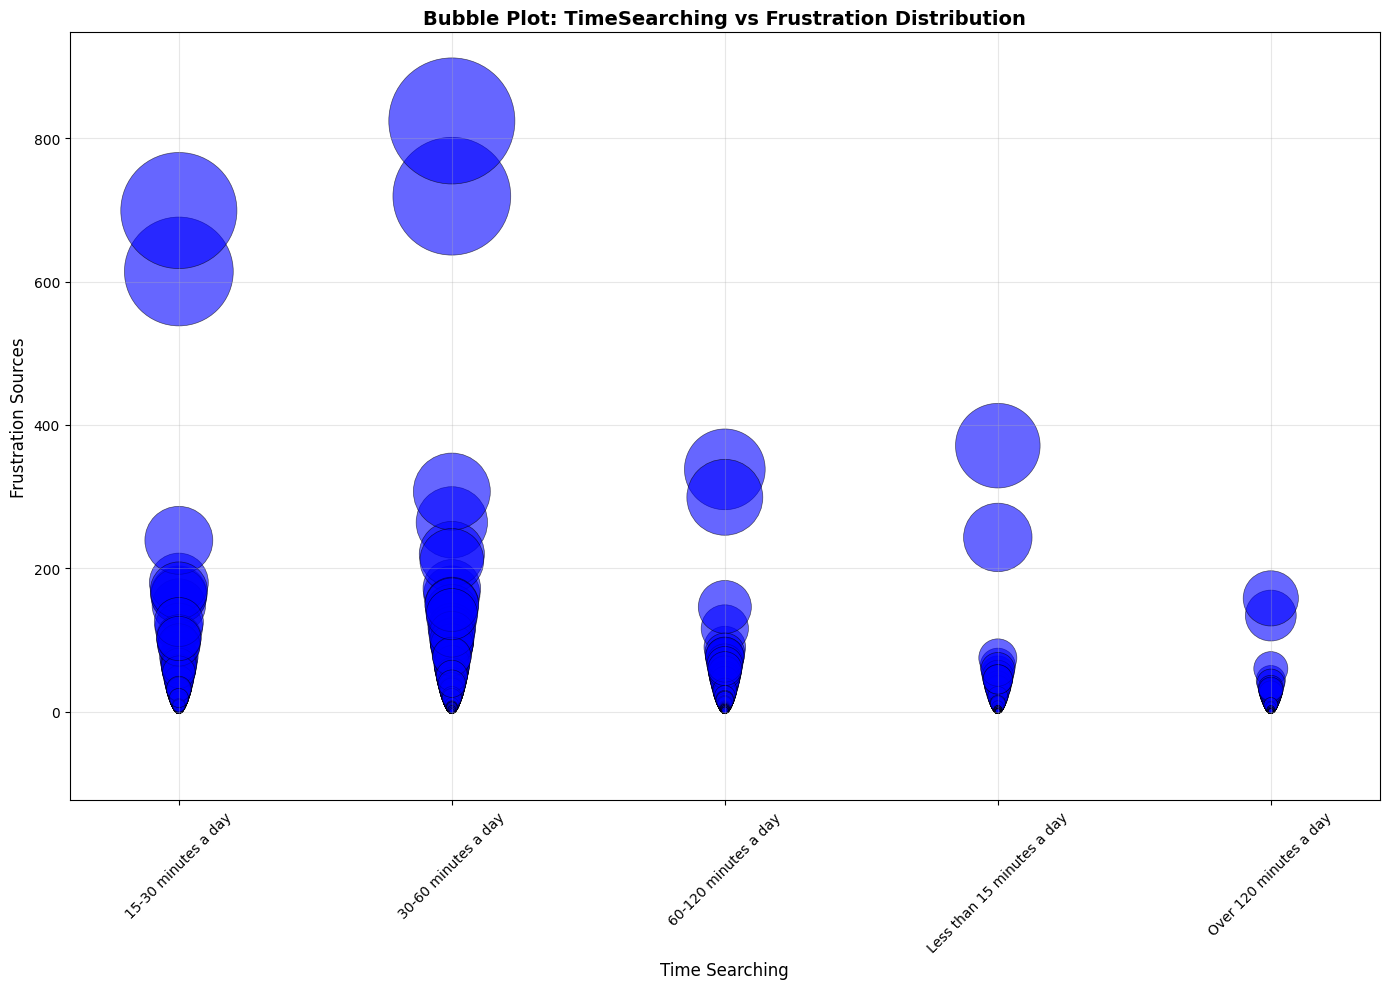

In [89]:
## Write your code here

# Query to get TimeSearching, Frustration, and Age data
QUERY = "SELECT TimeSearching, Frustration, Age FROM main"
df_bubble = pd.read_sql_query(QUERY, conn)

# Convert Age to numeric for bubble size
df_bubble['Age'] = df_bubble['Age'].astype(str).str.replace(' years old', '').str.replace('Under 18', '0').str.replace('18-24', '18').str.replace('25-34', '25').str.replace('35-44', '35').str.replace('45-54', '45').str.replace('55-64', '55').str.replace('65 years or older', '65').str.replace('Prefer not to say', '0').astype(float)

# Create pivot table for bubble plot
pivot = df_bubble.groupby(['TimeSearching', 'Frustration']).size().unstack(fill_value=0)

# Create bubble plot with padding to prevent cut-off
plt.figure(figsize=(14, 10))  # Increased size
for col in pivot.columns:
    plt.scatter(pivot.index, pivot[col], 
                s=pivot[col] * 10,  # Bubble size based on count
                alpha=0.6, edgecolors='black', linewidth=0.5, c='blue')
plt.title('Bubble Plot: TimeSearching vs Frustration Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Time Searching', fontsize=12)
plt.ylabel('Frustration Sources', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
# Add padding to prevent cut-off
plt.margins(x=0.1, y=0.15)
plt.tight_layout()
plt.show()


### Visualizing Composition of Data

**Pie Charts**

Create a pie chart of the top 5 databases(`DatabaseWantToWorkWith`) that respondents wish to learn next year.


In [90]:
QUERY = "SELECT DatabaseWantToWorkWith, COUNT(*) as count FROM main GROUP BY DatabaseWantToWorkWith ORDER BY count DESC LIMIT 10"
df_dist = pd.read_sql_query(QUERY, conn)
print(df_dist)

  DatabaseWantToWorkWith  count
0                    NaN  22879
1             PostgreSQL   3738
2      PostgreSQL;SQLite   1533
3                 SQLite   1476
4   Microsoft SQL Server   1431
5                  MySQL   1139
6                MongoDB    917
7       PostgreSQL;Redis    855
8     MongoDB;PostgreSQL    600
9       MySQL;PostgreSQL    504


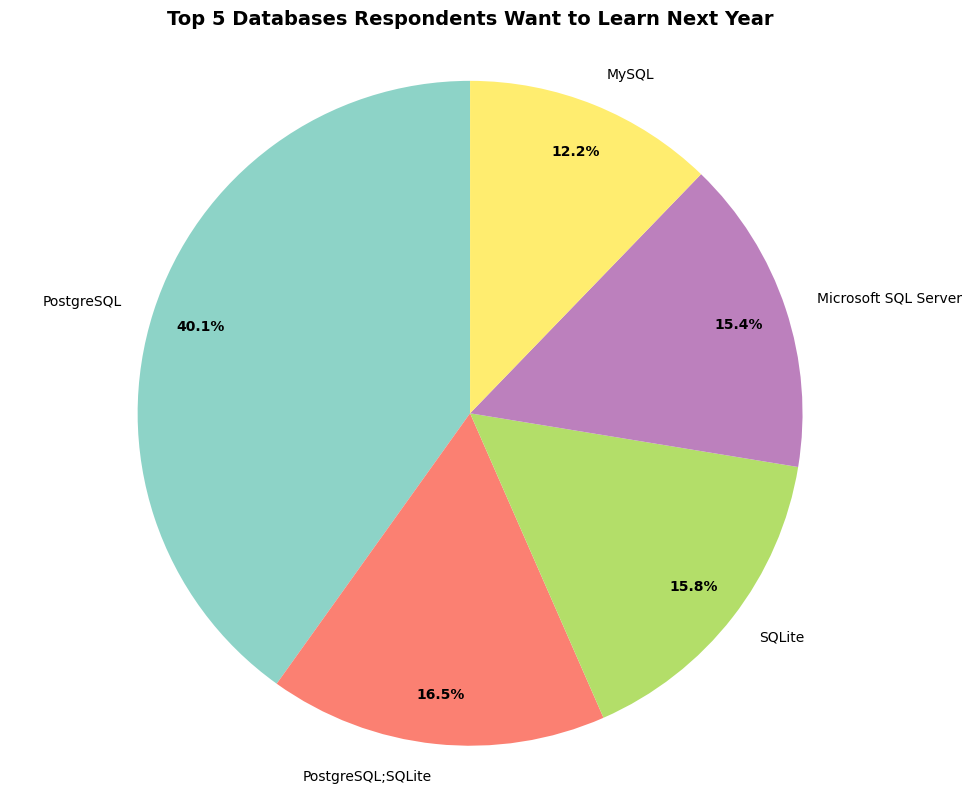

In [91]:
# Query to get DatabaseWantToWorkWith data (Top 5)
QUERY = """SELECT DatabaseWantToWorkWith, COUNT(*) as count 
           FROM main 
           WHERE DatabaseWantToWorkWith IS NOT NULL AND DatabaseWantToWorkWith != ''
           GROUP BY DatabaseWantToWorkWith 
           ORDER BY count DESC 
           LIMIT 5"""
df_databases = pd.read_sql_query(QUERY, conn)
# Create pie chart with better formatting
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(df_databases)))
wedges, texts, autotexts = plt.pie(
    df_databases['count'], 
    labels=df_databases['DatabaseWantToWorkWith'], 
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    pctdistance=0.85
)
# Add percentage text formatting
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
plt.title('Top 5 Databases Respondents Want to Learn Next Year', 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('equal')  # Equal aspect ratio ensures circular pie
plt.tight_layout()
plt.show()

**Stacked Charts** 

Create a stacked bar chart of median `TimeSearching` and `TimeAnswering` for the age group 30 to 35.


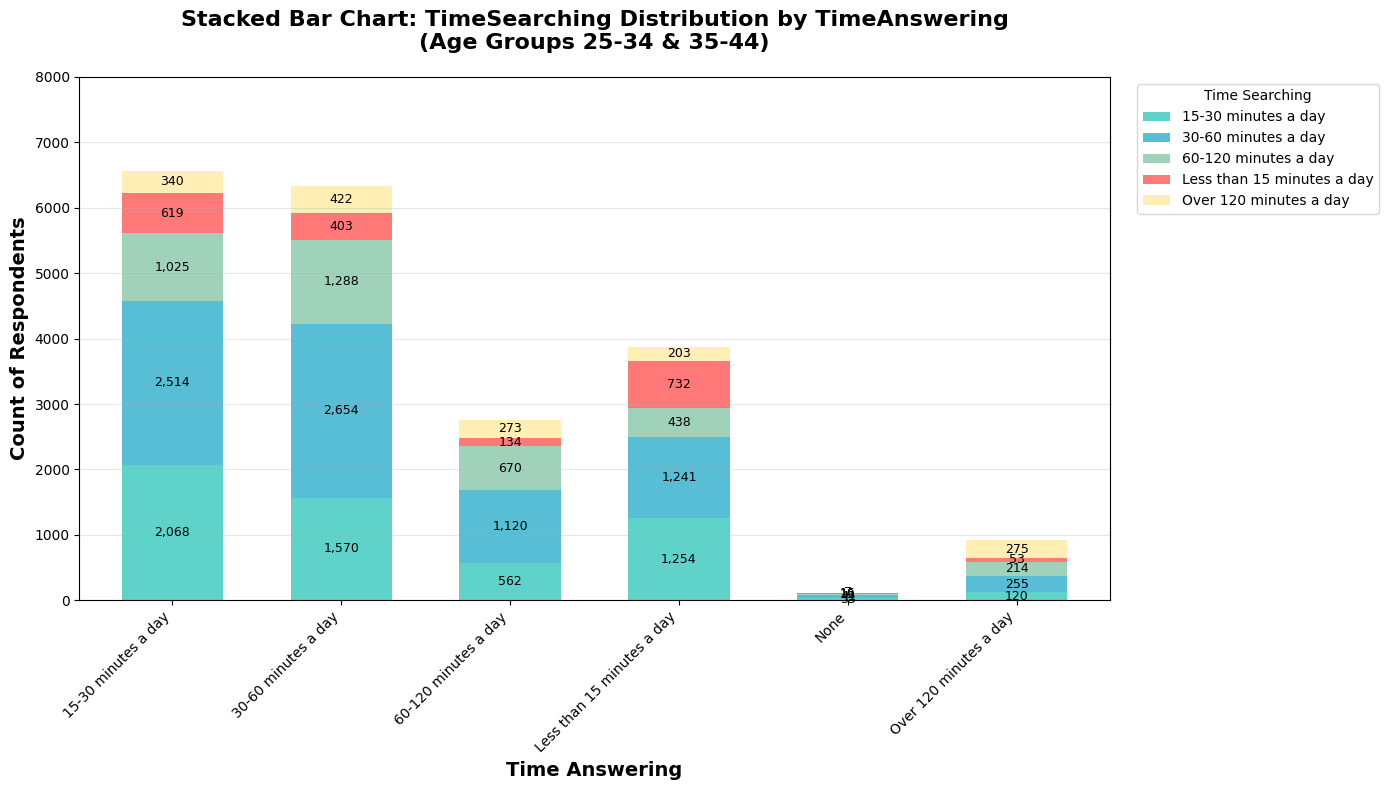


Chart Statistics:
  - Total bars (TimeAnswering categories): 6
  - Categories per bar (excluding None): 5
  - Maximum value in dataset: 18,221
  - Y-axis limit set to EXACTLY: 8000


In [92]:
# 1. Database Query and Data Retrieval
QUERY = """
SELECT 
    COALESCE(TimeSearching, 'None') as ts,
    COALESCE(TimeAnswering, 'None') as ta,
    COUNT(*) as cnt
FROM main
WHERE Age IN ('25-34 years old', '35-44 years old')
GROUP BY TimeSearching, TimeAnswering
ORDER BY ta, ts;
"""
df = pd.read_sql_query(QUERY, conn)

# 2. Pivot and Prepare Data
pivot_df = df.pivot(index="ta", columns="ts", values="cnt").fillna(0).astype(int)

# Drop 'None' columns from the visualization data so it doesn't affect stacking logic
plot_data = pivot_df.drop(columns=["None"], errors="ignore")

# Define colors for TimeSearching categories
colors = {
    "None": "#999999",
    "Less than 15 minutes a day": "#FF6B6B",
    "15-30 minutes a day": "#4ECDC4",
    "30-60 minutes a day": "#45B7D1",
    "60-120 minutes a day": "#96CEB4",
    "Over 120 minutes a day": "#FFEEAD",
}

# 3. Create Stacked Bar Chart
fig, ax = plt.subplots(figsize=(14, 8))

# Dynamically map colors to the remaining columns in plot_data
bar_colors = [colors.get(col, "#2E86AB") for col in plot_data.columns]

# Use native pandas/matplotlib stacking to prevent manual math alignment bugs
plot_data.plot(
    kind="bar", stacked=True, ax=ax, color=bar_colors, alpha=0.9, width=0.6
)

# Add labels and title
ax.set_xlabel("Time Answering", fontsize=14, fontweight="bold")
ax.set_ylabel("Count of Respondents", fontsize=14, fontweight="bold")
ax.set_title(
    "Stacked Bar Chart: TimeSearching Distribution by TimeAnswering\n(Age Groups 25-34 & 35-44)",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha="right")
plt.legend(title="Time Searching", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)

# Set EXACT y-axis limit to 8000
ax.set_ylim(0, 8000)

# 4. Add Value Labels on Bars Natively
for container in ax.containers:
    # Generate labels only for segments greater than 0
    labels = [
        f"{int(v.get_height()):,}" if v.get_height() > 0 else "" for v in container
    ]

    for rect, label in zip(container, labels):
        if label:
            # Calculate the exact center vertical position of the current bar segment
            y_pos = rect.get_y() + rect.get_height() / 2

            # CRITICAL FIX: Only print text if its position falls below your hard y-limit cut-off
            if y_pos < 8000:
                ax.text(
                    rect.get_x() + rect.get_width() / 2,
                    y_pos,
                    label,
                    ha="center",
                    va="center",
                    fontsize=9,
                )

# Adjust layout and save/display
plt.tight_layout()
plt.show()

# Display chart info
print("\nChart Statistics:")
print(f"  - Total bars (TimeAnswering categories): {len(pivot_df)}")
print(
    f"  - Categories per bar (excluding None): {len([c for c in pivot_df.columns if c != 'None'])}"
)
print(f"  - Maximum value in dataset: {pivot_df.max().max():,}")
print(f"  - Y-axis limit set to EXACTLY: 8000")

### Visualizing Comparison of Data

**Line Chart**

Plot the median `CompTotal` for all ages from 45 to 60.


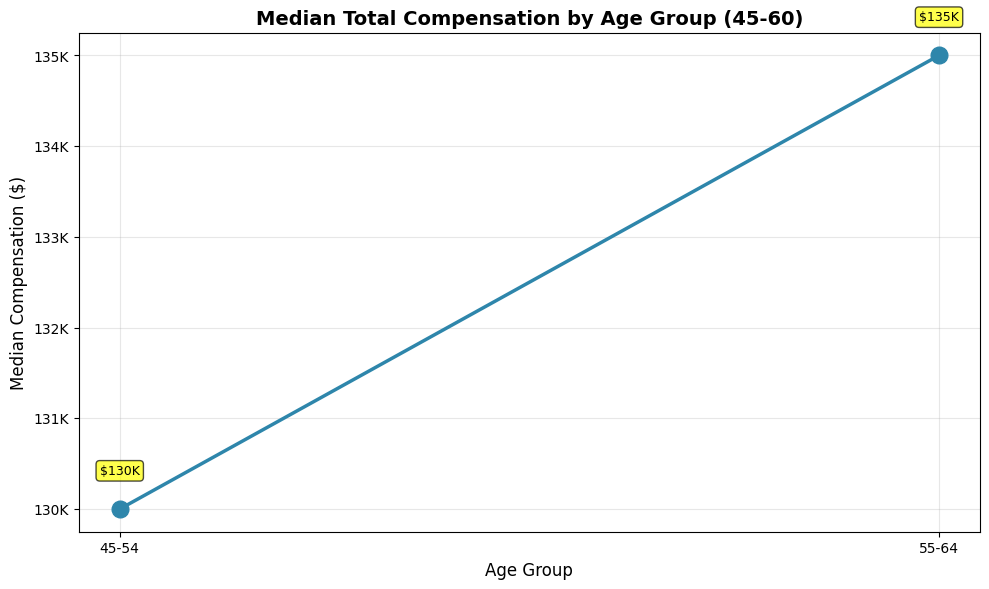

In [93]:
## Write your code here
# Query: Get CompTotal values for ages 45-60
QUERY = """
SELECT 
    CASE 
        WHEN Age LIKE '45%' THEN '45-54'
        WHEN Age LIKE '55%' THEN '55-64'
        ELSE NULL
    END as age_group,
    CompTotal
FROM main
WHERE Age IN ('45-54 years old', '55-64 years old')
  AND CompTotal IS NOT NULL;
"""
df = pd.read_sql_query(QUERY, conn)
# Calculate median per age group using Python
medians = df.groupby('age_group')['CompTotal'].median()
# Create line chart
plt.figure(figsize=(10, 6))
x = np.arange(len(medians))
plt.plot(
    x,
    medians.values,
    marker='o',
    linewidth=2.5,
    markersize=12,
    color='#2E86AB',
    linestyle='-'
)
# Add labels and title
plt.title('Median Total Compensation by Age Group (45-60)', fontsize=14, fontweight='bold')
plt.xlabel('Age Group', fontsize=12)
plt.ylabel('Median Compensation ($)', fontsize=12)
plt.xticks(x, medians.index.tolist())
plt.grid(True, alpha=0.3)
# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1000:.0f}K'))
# Add value labels on points
for i, (age, med) in enumerate(zip(medians.index.tolist(), medians.values)):
    plt.annotate(f'${med/1000:.0f}K', 
                 xy=(i, med), 
                 xytext=(0, 25),
                 textcoords='offset points',
                 ha='center',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
plt.tight_layout()
plt.show()

**Bar Chart**

Create a horizontal bar chart using the `MainBranch` column.


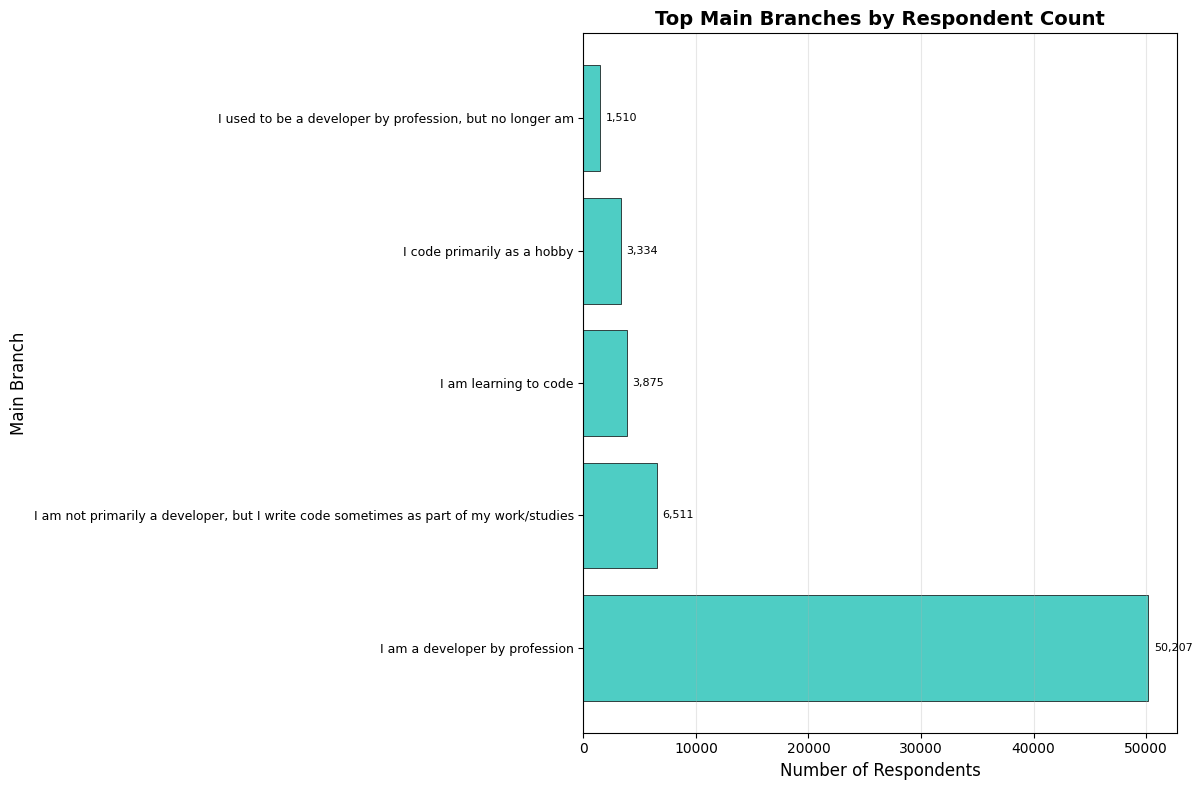

In [94]:
## Write your code here
# Query MainBranch data
QUERY = """
SELECT MainBranch, COUNT(*) as count
FROM main
WHERE MainBranch IS NOT NULL AND MainBranch != ''
GROUP BY MainBranch
ORDER BY count DESC;
"""
df_branch = pd.read_sql_query(QUERY, conn)
# Create horizontal bar chart with FIXED y-axis labels
plt.figure(figsize=(12, 8))
y_pos = range(len(df_branch))
# Use barh with proper label handling
ax = plt.barh(y_pos, df_branch['count'], color='#4ECDC4', edgecolor='black', linewidth=0.5)
# Add labels and title - FIXED: use set_yticklabels instead of rotation
plt.title('Top Main Branches by Respondent Count', fontsize=14, fontweight='bold')
plt.xlabel('Number of Respondents', fontsize=12)
plt.ylabel('Main Branch', fontsize=12)
# FIX: Use set_yticklabels with ha='right' to prevent overlap
plt.yticks(y_pos, df_branch['MainBranch'].tolist(), ha='right', fontsize=9)
# Add value labels on bars (offset from bar edge)
for i, (pos, count) in enumerate(zip(y_pos, df_branch['count'])):
    plt.text(count + 500, pos, f'{count:,}', va='center', ha='left', fontsize=8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Summary


In this lab, you focused on extracting and visualizing data from an RDBMS using SQL queries and SQLite. You applied various visualization techniques, including:

- Histograms to display the distribution of CompTotal.
- Box plots to show the spread of ages.
- Scatter plots and bubble plots to explore relationships between variables like Age, WorkExp, `TimeSearching` and `TimeAnswering`.
- Pie charts and stacked charts to visualize the composition of data.
- Line charts and bar charts to compare data across categories.


### Close the Database Connection

Once the lab is complete, ensure to close the database connection:


In [95]:
conn.close()

## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
